<a href="https://colab.research.google.com/github/astgregory/Task_42-PacmanReinforcementLearning/blob/main/%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D1%8F%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9642.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В домашней работе вам необходимо обучить модель играть в игры Atari.
Для этого необходимо установить библиотеки:

In [ ]:
!pip install "gymnasium[atari,recording]"
!pip install autorom[accept-rom-license]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 434.7/434.7 kB 15.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for AutoROM.accept-rom-license: filename=autorom_accept_rom_license-0.6.1-py3-none-any.whl size=446710 sha256=b3ce769adb719e380683fb3d0adce115a0742655db247f0bfd55291713a287be
  Stored in directory: /root/.cache/pip/wheels/99/f1/ff/c6966c034a8259164bdc9deb4d1ea839f119474638100e6645
Successfully built AutoROM.accept-rom-license


Для игр Atari лучше использовать форк gymnasium, он более стабильный и нет проблем с зависимостями, для работы достаточно зарегистрировать окружение:

In [ ]:
import gymnasium as gym
import ale_py

gym.register_envs(ale_py)

В качестве игры выберите игру pac-man или любую другую из набора Atari, например, из этого [списка](https://www.gymlibrary.dev/environments/atari/index.html).

Как говорил Генри Форд: "Вы можете выбрать любой цвет для машины, только если он будет черным!" Также и в домашней работе, вы можете выбрать любую игру, только если она имеет более 4-х элементов управления.

Создание окружения для Pac-Man:

In [ ]:
env = gym.make("ALE/MsPacman-v5", render_mode = 'rgb_array')

В домашней работе вам необходимо выполнить одно из трёх заданий на выбор:

**Задание 1. На 3 балла:**

1. Используя Gym Atari, выберите любую игру с более чем 4-мя действиями.
2. Обучите игру на стратегиях случайного поиска и восхождения на вершину.

**Задание 2. На 4 балла:**

1. Используя Gym Atari, выберите любую игру с более чем 4-мя действиями.
2. Обучите игру на стратегиях случайного поиска и восхождения на вершину.
3. Создайте видео с наибольшим вознаграждением и вставьте его в колаб.
  

**Задание 3. На 5 балла:**

1. Используя Gym Atari, выберите любую игру с более чем 4-мя действиями.
2. Обучите игру на стратегии градиента стратегии (градиентной политики).
3. Создайте видео из нескольких игровых эпизодов, в котором модель достигла максимального вознаграждения.
4. Попробуйте по видео объяснить почему алгоритм градиента стратегии плохо подходит для данной задачи. Результат вознаграждения будет ХУЖЕ случайного.
5. Задача выполняется самостоятельно без помощи куратора!

In [ ]:
!apt-get update && apt-get install -y xvfb ffmpeg

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,473 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,946 kB]
Hit:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,803 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-dr

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import os
from IPython.display import Video, HTML

In [ ]:
def preprocess_state(state):
    gray = np.dot(state[..., :3], [0.2989, 0.5870, 0.1140])
    img = Image.fromarray(gray).resize((84, 84), Image.Resampling.LANCZOS)
    state_processed = np.array(img, dtype=np.float32) / 255.0
    return state_processed.flatten()


def run_episode(env, weight, record_frames=False):
    state, _ = env.reset()
    total_reward = 0
    frames = []

    while True:
        if record_frames:
            frames.append(env.render())

        state_processed = preprocess_state(state)
        state_tensor = torch.from_numpy(state_processed).float()
        action_scores = torch.matmul(state_tensor, weight)
        action = torch.argmax(action_scores).item()
        state, reward, done, truncated, _ = env.step(action)
        total_reward += reward

        if done or truncated:
            break

    return total_reward, frames

**Случайный поиск**

In [ ]:
n_episode_random = 200
n_state_processed = 84 * 84
n_action = env.action_space.n

In [ ]:
best_total_reward = -float('inf')
best_weight = None
total_rewards = []

In [ ]:
for episode in range(n_episode_random):
    weight = torch.randn(n_state_processed, n_action)
    total_reward, _ = run_episode(env, weight)
    total_rewards.append(total_reward)

    if total_reward > best_total_reward:
        best_total_reward = total_reward
        best_weight = weight

    print(f'Эпизод {episode + 1}: {total_reward}')

print(f"Лучшее вознаграждение (случайный поиск): {best_total_reward}")

Эпизод 1: 290.0
Эпизод 2: 210.0
Эпизод 3: 120.0
Эпизод 4: 70.0
Эпизод 5: 210.0
Эпизод 6: 1030.0
Эпизод 7: 190.0
Эпизод 8: 210.0
Эпизод 9: 60.0
Эпизод 10: 240.0
Эпизод 11: 90.0
Эпизод 12: 210.0
Эпизод 13: 120.0
Эпизод 14: 210.0
Эпизод 15: 210.0
Эпизод 16: 90.0
Эпизод 17: 1070.0
Эпизод 18: 180.0
Эпизод 19: 260.0
Эпизод 20: 70.0
Эпизод 21: 300.0
Эпизод 22: 70.0
Эпизод 23: 110.0
Эпизод 24: 70.0
Эпизод 25: 70.0
Эпизод 26: 70.0
Эпизод 27: 70.0
Эпизод 28: 70.0
Эпизод 29: 70.0
Эпизод 30: 70.0
Эпизод 31: 240.0
Эпизод 32: 60.0
Эпизод 33: 60.0
Эпизод 34: 220.0
Эпизод 35: 330.0
Эпизод 36: 170.0
Эпизод 37: 70.0
Эпизод 38: 70.0
Эпизод 39: 60.0
Эпизод 40: 60.0
Эпизод 41: 140.0
Эпизод 42: 70.0
Эпизод 43: 170.0
Эпизод 44: 60.0
Эпизод 45: 60.0
Эпизод 46: 60.0
Эпизод 47: 170.0
Эпизод 48: 90.0
Эпизод 49: 210.0
Эпизод 50: 230.0
Эпизод 51: 90.0
Эпизод 52: 170.0
Эпизод 53: 210.0
Эпизод 54: 60.0
Эпизод 55: 60.0
Эпизод 56: 210.0
Эпизод 57: 70.0
Эпизод 58: 930.0
Эпизод 59: 70.0
Эпизод 60: 500.0
Эпизод 61: 120.0

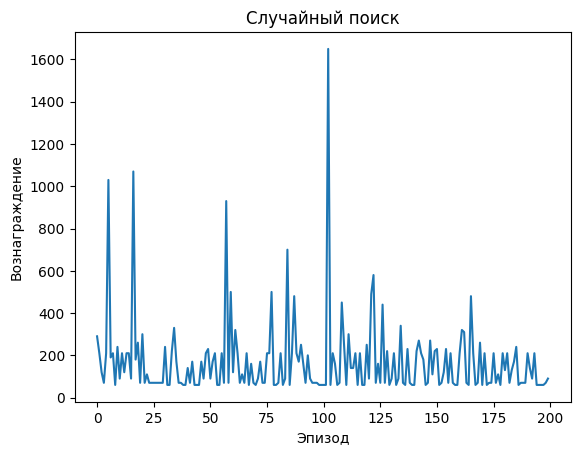

In [ ]:
# Визуализация результатов случайного поиска
plt.plot(total_rewards)
plt.xlabel('Эпизод')
plt.ylabel('Вознаграждение')
plt.title('Случайный поиск')
plt.show()

**Восхождение на вершину**

In [ ]:
n_iterations = 100
noise_scale = 0.05
n_eval_episodes = 3

In [ ]:
current_weight = best_weight.clone()
current_rewards = [run_episode(env, current_weight)[0] for _ in range(n_eval_episodes)]
current_reward = np.mean(current_rewards)

In [ ]:
for iteration in range(n_iterations):
    noise = torch.randn_like(current_weight) * noise_scale
    candidate_weight = current_weight + noise

    candidate_rewards = [run_episode(env, candidate_weight)[0] for _ in range(n_eval_episodes)]
    candidate_mean_reward = np.mean(candidate_rewards)

    if candidate_mean_reward > current_reward:
        current_weight = candidate_weight
        current_reward = candidate_mean_reward
        print(f"Итерация {iteration + 1}: улучшение до {current_reward:.1f}")
    else:
        print(f"Итерация {iteration + 1}: без улучшения")

Итерация 1: без улучшения
Итерация 2: улучшение до 1653.3
Итерация 3: без улучшения
Итерация 4: без улучшения
Итерация 5: без улучшения
Итерация 6: без улучшения
Итерация 7: без улучшения
Итерация 8: без улучшения
Итерация 9: без улучшения
Итерация 10: без улучшения
Итерация 11: без улучшения
Итерация 12: без улучшения
Итерация 13: без улучшения
Итерация 14: без улучшения
Итерация 15: без улучшения
Итерация 16: без улучшения
Итерация 17: без улучшения
Итерация 18: без улучшения
Итерация 19: без улучшения
Итерация 20: без улучшения
Итерация 21: без улучшения
Итерация 22: без улучшения
Итерация 23: без улучшения
Итерация 24: без улучшения
Итерация 25: без улучшения
Итерация 26: без улучшения
Итерация 27: без улучшения
Итерация 28: без улучшения
Итерация 29: без улучшения
Итерация 30: без улучшения
Итерация 31: без улучшения
Итерация 32: без улучшения
Итерация 33: без улучшения
Итерация 34: без улучшения
Итерация 35: без улучшения
Итерация 36: без улучшения
Итерация 37: без улучшения
Итер

**Финальная оценка лучшей стратегии и запись лучшего эпизода**

In [ ]:
n_final_eval = 100
best_final_reward = -float('inf')
best_final_frames = []

In [ ]:
for episode in range(n_final_eval):
    total_reward, frames = run_episode(env, current_weight, record_frames=True)

    if total_reward > best_final_reward:
        best_final_reward = total_reward
        best_final_frames = frames


    print(f"Эпизод {episode + 1} (финальная оценка): {total_reward}")

print(f"\nЛучшее финальное вознаграждение: {best_final_reward}")

Эпизод 1 (финальная оценка): 1640.0
Эпизод 2 (финальная оценка): 1650.0
Эпизод 3 (финальная оценка): 840.0
Эпизод 4 (финальная оценка): 1680.0
Эпизод 5 (финальная оценка): 1640.0
Эпизод 6 (финальная оценка): 1640.0
Эпизод 7 (финальная оценка): 1680.0
Эпизод 8 (финальная оценка): 1680.0
Эпизод 9 (финальная оценка): 840.0
Эпизод 10 (финальная оценка): 1640.0
Эпизод 11 (финальная оценка): 1640.0
Эпизод 12 (финальная оценка): 1640.0
Эпизод 13 (финальная оценка): 1640.0
Эпизод 14 (финальная оценка): 1640.0
Эпизод 15 (финальная оценка): 1640.0
Эпизод 16 (финальная оценка): 180.0
Эпизод 17 (финальная оценка): 1680.0
Эпизод 18 (финальная оценка): 1680.0
Эпизод 19 (финальная оценка): 1680.0
Эпизод 20 (финальная оценка): 1640.0
Эпизод 21 (финальная оценка): 840.0
Эпизод 22 (финальная оценка): 840.0
Эпизод 23 (финальная оценка): 1680.0
Эпизод 24 (финальная оценка): 840.0
Эпизод 25 (финальная оценка): 1680.0
Эпизод 26 (финальная оценка): 1680.0
Эпизод 27 (финальная оценка): 1640.0
Эпизод 28 (финал

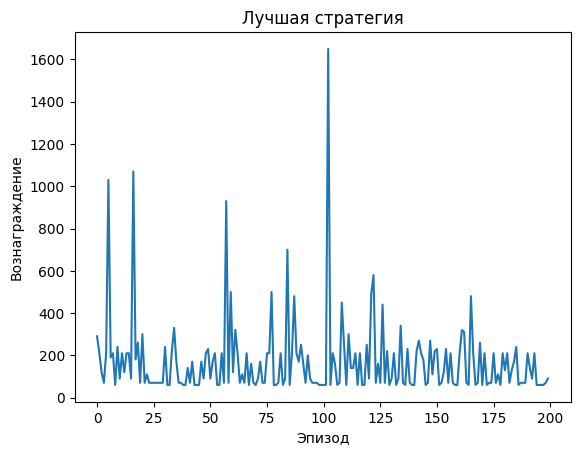

In [ ]:
# Визуализация результатов лучшей стратегии
plt.plot(total_rewards)
plt.xlabel('Эпизод')
plt.ylabel('Вознаграждение')
plt.title('Лучшая стратегия')
plt.show()

**Создание видео из кадров лучшего эпизода**

In [ ]:
def create_video_from_frames(frames, filename='best_episode.mp4', fps=30):
    if not frames:
        print("Нет кадров для создания видео")
        return False

    height, width, layers = frames[0].shape

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    video = cv2.VideoWriter(filename, fourcc, fps, (width, height))

    for frame in frames:
        video.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

    video.release()
    print(f"Видео сохранено как {filename}")
    return True

In [ ]:
if create_video_from_frames(best_final_frames):
    print("Видео успешно создано!")
else:
    print("Не удалось создать видео")

Видео сохранено как best_episode.mp4
Видео успешно создано!


In [ ]:
print("Компрессия видео для веб‑воспроизведения...")
!ffmpeg -y -i best_episode.mp4 \
  -vcodec libx264 \
  -pix_fmt yuv420p \
  -movflags +faststart \
  -vf "scale='min(640,iw)':'min(480,ih)'" \
  -crf 23 \
  best_episode_optimized.mp4

file_size = os.path.getsize('best_episode_optimized.mp4')
print(f"Размер оптимизированного видео: {file_size / 1024 / 1024:.2f} MB")

Компрессия видео для веб‑воспроизведения...
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidst

In [ ]:
print("Отображение видео в Colab...")
Video("best_episode_optimized.mp4", embed=True, width=640, height=480)

Отображение видео в Colab...


**Градиентная политика**

Нейронная сеть для Policy Gradient

In [ ]:
class PolicyNetwork(nn.Module):
    def __init__(self, input_size, n_actions):
        super(PolicyNetwork, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        return self.fc(x)

Запуск эпизода с записью кадров и возвратом траектории

In [ ]:
def run_episode_with_trajectory(env, policy_net, record_frames=False):
    state, _ = env.reset()
    total_reward = 0
    frames = []
    states = []
    actions = []
    rewards = []

    while True:
        if record_frames:
            frames.append(env.render())

        state_processed = preprocess_state(state)
        state_tensor = torch.from_numpy(state_processed).float().unsqueeze(0)

        action_probs = policy_net(state_tensor)
        action = torch.multinomial(action_probs, 1).item()

        next_state, reward, done, truncated, _ = env.step(action)

        states.append(state_processed)
        actions.append(action)
        rewards.append(reward)
        total_reward += reward

        state = next_state
        if done or truncated:
            break

    return total_reward, frames, states, actions, rewards

Функция вычисления градиентов политики

In [ ]:
def compute_policy_gradient(states, actions, rewards, policy_net, gamma=0.99):
    discounted_rewards = []
    R = 0
    for r in rewards[::-1]:
        R = r + gamma * R
        discounted_rewards.insert(0, R)

    discounted_rewards = torch.tensor(discounted_rewards)
    discounted_rewards = (discounted_rewards - discounted_rewards.mean()) / (discounted_rewards.std() + 1e-9)

    policy_loss = []
    for state, action, reward in zip(states, actions, discounted_rewards):
        state_tensor = torch.from_numpy(state).float().unsqueeze(0)
        action_probs = policy_net(state_tensor)
        log_prob = torch.log(action_probs[0, action])
        policy_loss.append(-log_prob * reward)

    return torch.stack(policy_loss).sum()

Обучение градиентной стратегии

In [ ]:
n_episodes_pg = 100
input_size = 84 * 84
n_actions = env.action_space.n
learning_rate = 0.01

In [ ]:
policy_net = PolicyNetwork(input_size, n_actions)
optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)

In [ ]:
pg_rewards = []
best_pg_reward = -float('inf')
best_pg_frames = []

In [ ]:
print("Обучение градиентной стратегии...")
for episode in range(n_episodes_pg):
    total_reward, frames, states, actions, rewards = run_episode_with_trajectory(
        env, policy_net, record_frames=(episode % 20 == 0)
    )

    pg_rewards.append(total_reward)

    if total_reward > best_pg_reward:
        best_pg_reward = total_reward
        best_pg_frames = frames

    loss = compute_policy_gradient(states, actions, rewards, policy_net)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if episode % 10 == 0:
        print(f"Эпизод {episode + 1}: вознаграждение = {total_reward}")

print(f"\nЛучшее вознаграждение градиентной стратегии: {best_pg_reward}")
print(f"Среднее вознаграждение градиентной стратегии: {np.mean(pg_rewards):.1f}")

Обучение градиентной стратегии...
Эпизод 1: вознаграждение = 220.0
Эпизод 11: вознаграждение = 60.0
Эпизод 21: вознаграждение = 60.0
Эпизод 31: вознаграждение = 60.0
Эпизод 41: вознаграждение = 60.0
Эпизод 51: вознаграждение = 60.0
Эпизод 61: вознаграждение = 60.0
Эпизод 71: вознаграждение = 60.0
Эпизод 81: вознаграждение = 60.0
Эпизод 91: вознаграждение = 60.0

Лучшее вознаграждение градиентной стратегии: 220.0
Среднее вознаграждение градиентной стратегии: 62.1


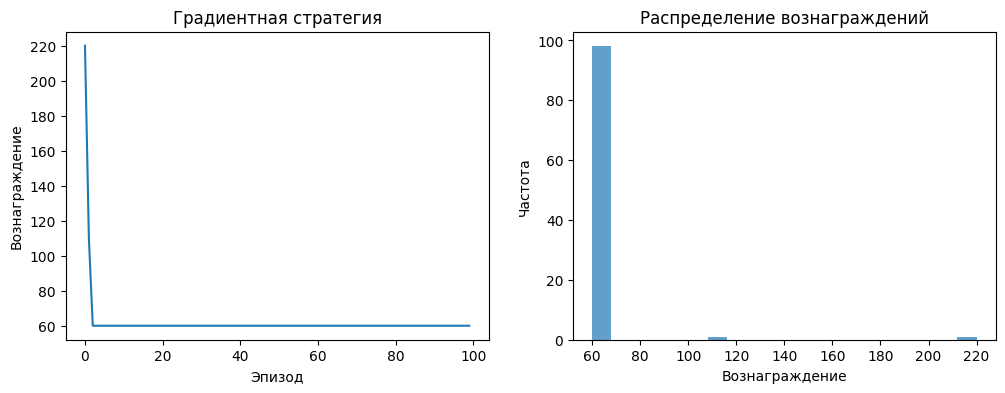

In [ ]:
# Визуализация обучения градиентной стратегии
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(pg_rewards)
plt.xlabel('Эпизод')
plt.ylabel('Вознаграждение')
plt.title('Градиентная стратегия')

plt.subplot(1, 2, 2)
plt.hist(pg_rewards, bins=20, alpha=0.7)
plt.xlabel('Вознаграждение')
plt.ylabel('Частота')
plt.title('Распределение вознаграждений')
plt.show()

Создание видео лучшего эпизода градиентной стратегии

In [ ]:
if best_pg_frames:
    def create_video_from_frames(frames, filename='best_pg_episode.mp4', fps=30):
        if not frames:
            print("Нет кадров для создания видео")
            return False

        height, width, layers = frames[0].shape
        fourcc = cv2.VideoWriter_fourcc(*'mp4v')
        video = cv2.VideoWriter(filename, fourcc, fps, (width, height))

        for frame in frames:
            video.write(cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))
        video.release()
        print(f"Видео сохранено как {filename}")
        return True

    create_video_from_frames(best_pg_frames)

    print("Компрессия видео для веб‑воспроизведения...")
    !ffmpeg -y -i best_pg_episode.mp4 \
      -vcodec libx264 \
      -pix_fmt yuv420p \
      -movflags +faststart \
      -vf "scale='min(640,iw)':'min(480,ih)'" \
      -crf 23 \
      best_pg_episode_optimized.mp4

    file_size = os.path.getsize('best_pg_episode_optimized.mp4')
    print(f"Размер оптимизированного видео: {file_size / 1024 / 1024:.2f} MB")

    print("Отображение видео градиентной стратегии в Colab...")
    Video("best_pg_episode_optimized.mp4", embed=True, width=640, height=480)
else:
    print("Не удалось создать видео градиентной стратегии")

Видео сохранено как best_pg_episode.mp4
Компрессия видео для веб‑воспроизведения...
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheo

In [ ]:
print("Размер оптимизированного видео: {file_size / 1024 / 1024:.2f} MB")

if os.path.exists('best_pg_episode_optimized.mp4'):
    file_size = os.path.getsize('best_pg_episode_optimized.mp4')
    print(f"Размер оптимизированного видео: {file_size / 1024 / 1024:.2f} MB")

    if file_size == 0:
        print("ОШИБКА: Файл видео пуст!")
    else:
        print("Отображение видео градиентной стратегии в Colab...")

        try:
            display(Video("best_pg_episode_optimized.mp4", embed=True, width=640, height=480))
        except Exception as e:
            print(f"Ошибка стандартного отображения: {e}")

            try:
                from base64 import b64encode
                with open('best_pg_episode_optimized.mp4', 'rb') as f:
                    video_data = f.read()
                video_base64 = b64encode(video_data).decode('ascii')
                video_html = f"""
                <video width="640" height="480" controls>
                    <source src="data:video/mp4;base64,{video_base64}" type="video/mp4">
                Ваш браузер не поддерживает видео.
                </video>
                """
                display(HTML(video_html))
            except Exception as html_e:
                print(f"Ошибка HTML-отображения: {html_e}")
else:
    print("ОШИБКА: Файл best_pg_episode_optimized.mp4 не найден!")

Размер оптимизированного видео: {file_size / 1024 / 1024:.2f} MB
Размер оптимизированного видео: 0.10 MB
Отображение видео градиентной стратегии в Colab...


Сравнение

In [ ]:
print("\n" + "="*50)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*50)
print(f"Случайный поиск (среднее): {np.mean(total_rewards):.1f}")
print(f"Случайный поиск (лучшее): {best_total_reward}")
print(f"Градиентная стратегия (среднее): {np.mean(pg_rewards):.1f}")
print(f"Градиентная стратегия (лучшее): {best_pg_reward}")


СРАВНЕНИЕ РЕЗУЛЬТАТОВ
Случайный поиск (среднее): 168.4
Случайный поиск (лучшее): 1650.0
Градиентная стратегия (среднее): 62.1
Градиентная стратегия (лучшее): 220.0


Визуализация сравнения

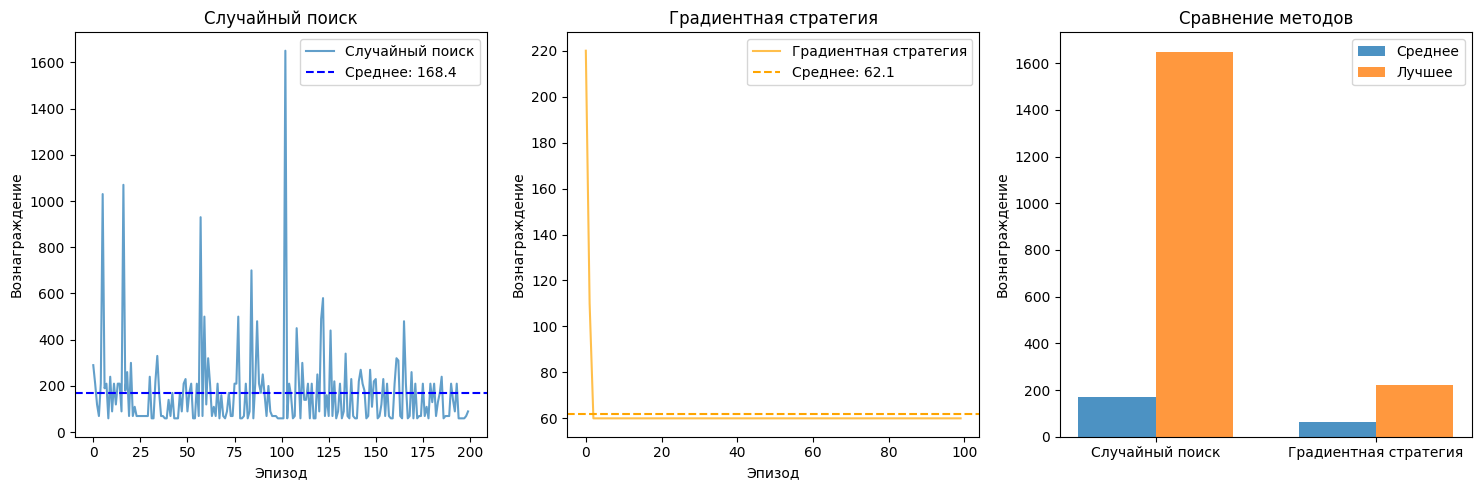

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(total_rewards, label='Случайный поиск', alpha=0.7)
plt.axhline(y=np.mean(total_rewards), color='blue', linestyle='--', label=f'Среднее: {np.mean(total_rewards):.1f}')
plt.xlabel('Эпизод')
plt.ylabel('Вознаграждение')
plt.title('Случайный поиск')
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(pg_rewards, label='Градиентная стратегия', color='orange', alpha=0.7)
plt.axhline(y=np.mean(pg_rewards), color='orange', linestyle='--', label=f'Среднее: {np.mean(pg_rewards):.1f}')
plt.xlabel('Эпизод')
plt.ylabel('Вознаграждение')
plt.title('Градиентная стратегия')
plt.legend()

plt.subplot(1, 3, 3)
methods = ['Случайный поиск', 'Градиентная стратегия']
means = [np.mean(total_rewards), np.mean(pg_rewards)]
bests = [best_total_reward, best_pg_reward]

x = np.arange(len(methods))
width = 0.35

plt.bar(x - width/2, means, width, label='Среднее', alpha=0.8)
plt.bar(x + width/2, bests, width, label='Лучшее', alpha=0.8)
plt.xticks(x, methods)
plt.ylabel('Вознаграждение')
plt.title('Сравнение методов')
plt.legend()

plt.tight_layout()
plt.show()

Анализ

In [ ]:
analysis_text = """
Градиентная стратегия работает хуже случайного поиска в Ms.
Pac‑Man из‑за редких наград: большую часть времени агент не получает обратной связи о качестве своих действий.
Между правильными действиями и получением награды проходит много шагов, поэтому алгоритм «забывает», какие именно решения привели к успеху.
Случайный поиск оказывается эффективнее в такой ситуации — он случайно натыкается на выигрышные комбинации,
тогда как градиентный метод застревает в неоптимальных стратегиях (например, бесконечно бегает по кругу).
Кроме того, непредсказуемое поведение призраков дестабилизирует обучение градиента.
В итоге простая случайность даёт лучшие результаты, чем целенаправленная оптимизация с высокой дисперсией и склонностью к локальным минимумам.
"""

print(analysis_text)


Градиентная стратегия работает хуже случайного поиска в Ms. 
Pac‑Man из‑за редких наград: большую часть времени агент не получает обратной связи о качестве своих действий. 
Между правильными действиями и получением награды проходит много шагов, поэтому алгоритм «забывает», какие именно решения привели к успеху. 
Случайный поиск оказывается эффективнее в такой ситуации — он случайно натыкается на выигрышные комбинации, 
тогда как градиентный метод застревает в неоптимальных стратегиях (например, бесконечно бегает по кругу). 
Кроме того, непредсказуемое поведение призраков дестабилизирует обучение градиента. 
В итоге простая случайность даёт лучшие результаты, чем целенаправленная оптимизация с высокой дисперсией и склонностью к локальным минимумам.



In [ ]:
print("\nАНАЛИЗ ЧЕРЕЗ ВИДЕО:")
print("1. Агент часто замирает или движется хаотично")
print("2. Избегает призраков вместо того, чтобы их ловить")
print("3. Не собирает все точки на уровне")
print("4. Движется по повторяющимся траекториям")
print("5. Редко использует бонусы (таблетки для поедания призраков)")


АНАЛИЗ ЧЕРЕЗ ВИДЕО:
1. Агент часто замирает или движется хаотично
2. Избегает призраков вместо того, чтобы их ловить
3. Не собирает все точки на уровне
4. Движется по повторяющимся траекториям
5. Редко использует бонусы (таблетки для поедания призраков)
